In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Update the path if needed
file_path = "Latency_Percieved_Live_Stream_Rayban_Results.csv"
df = pd.read_csv(file_path)

df.head()

,Test,Latency G2S,Latenct S2C,Letency End-End
0,Insta Live /n RB-Meta /n BT-Classic,4570.714286,10297.42857,14868.142860
1,Insta Live /n RB-Meta /n Wifi-Direct,2670.714286,8625.571429,11296.285710
2,Insta Live /n Phone,-,-,8588.571429
3,Messenger /n RB-Meta /n BT-Classic,174.4285714,58.14285714,232.571429
4,Messenger /n Phone,-,-,58.142857


In [4]:
# --- Cell 3: Check columns and prepare data ---
print("Columns:", df.columns.tolist())

# Depending on your data structure, you may need to adjust which columns to plot.
# Example: If you have columns like "Category", "Low", "Medium", "High"
# we can use the first column as index and the rest as stacked bars:
index_col = df.columns[0]         # e.g., 'Category'
value_cols = df.columns[1:4]       # e.g., ['Low', 'Medium', 'High']

df_plot = df.set_index(index_col)[value_cols]
df_plot.head()

Columns: ['Test', 'Latency G2S', 'Latenct S2C', 'Letency End-End']


,Latency G2S,Latenct S2C,Letency End-End
Test,,,
Insta Live /n RB-Meta /n BT-Classic,4570.714286,10297.42857,14868.142860
Insta Live /n RB-Meta /n Wifi-Direct,2670.714286,8625.571429,11296.285710
Insta Live /n Phone,-,-,8588.571429
Messenger /n RB-Meta /n BT-Classic,174.4285714,58.14285714,232.571429
Messenger /n Phone,-,-,58.142857


Data loaded and prepared successfully. Ready for plotting.


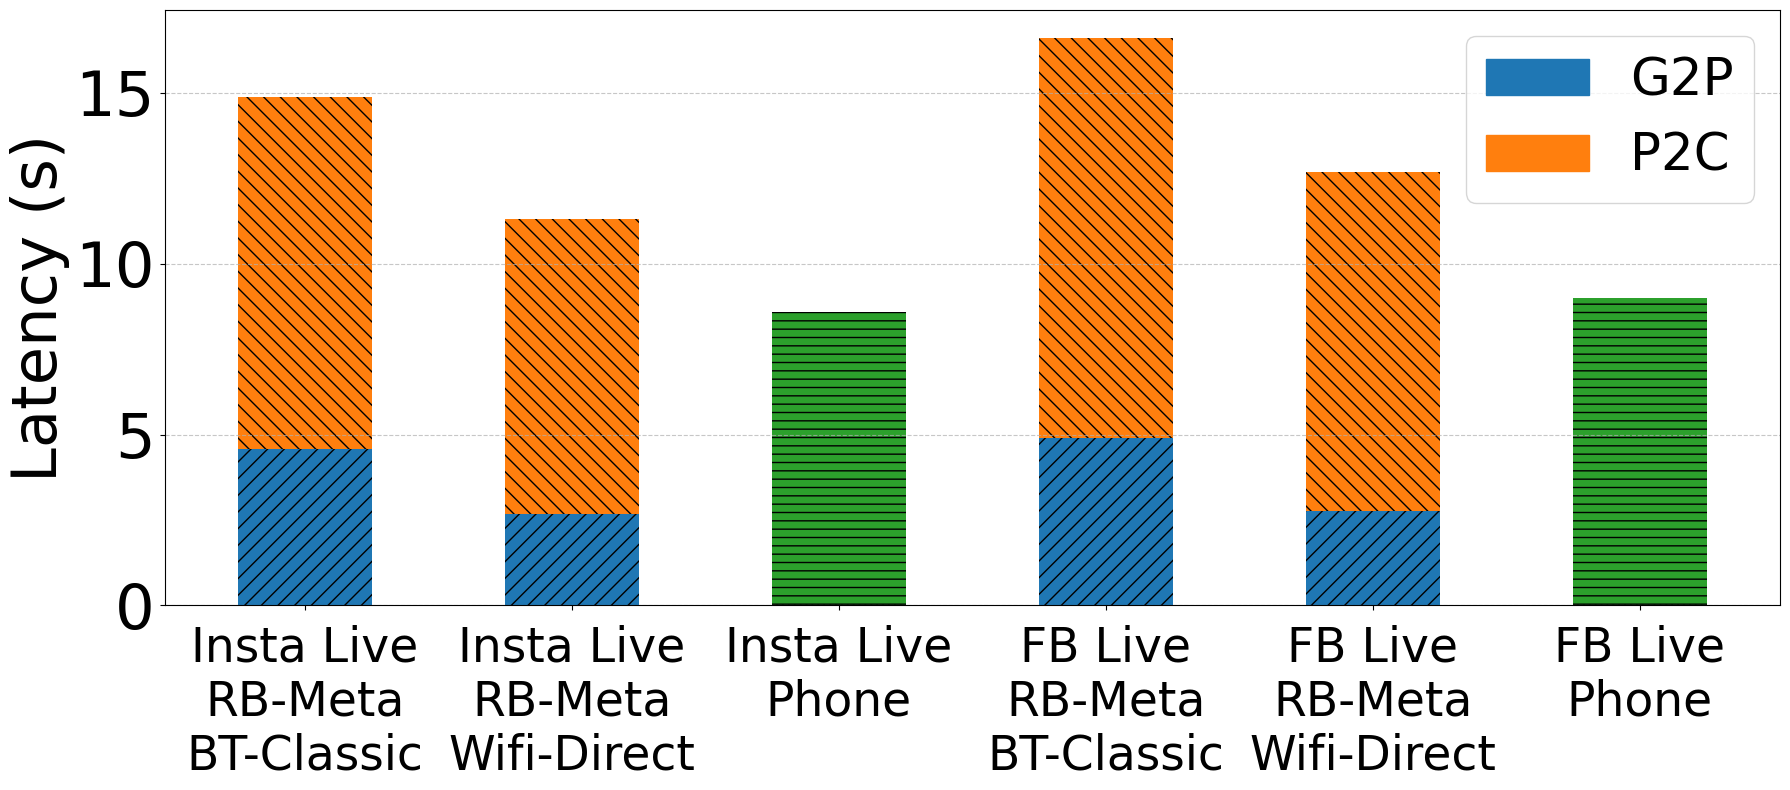

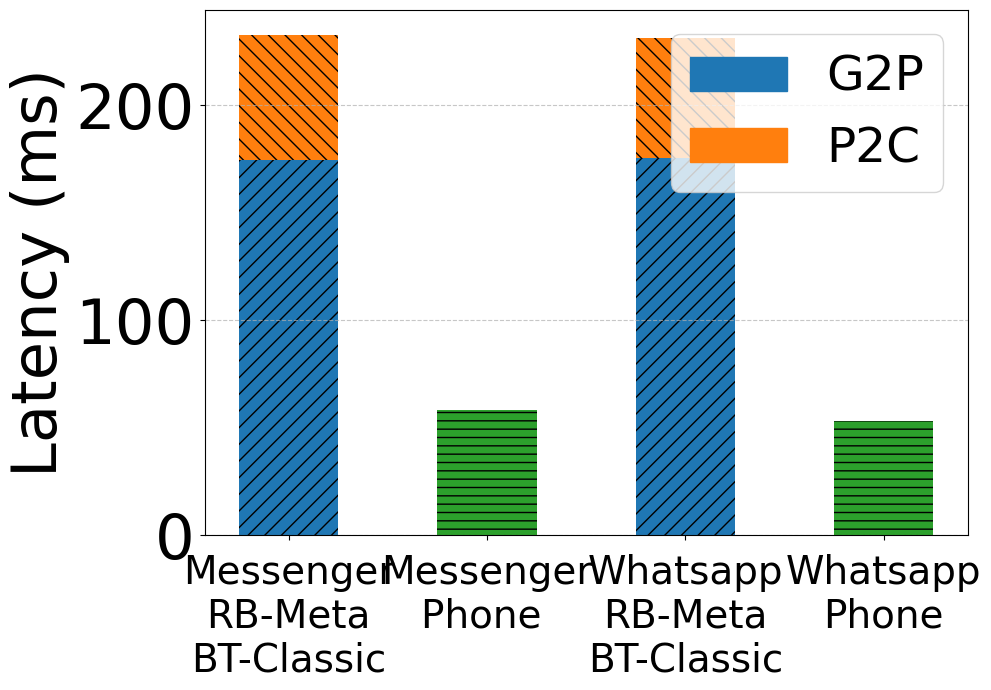

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Load and Combine Datasets ---
# Corrected the filename to match the uploaded file.
original_file_name = 'Latency_Percieved_Live_Stream_Rayban_Results.csv'
new_file_name = 'FB_Whatsapp_Latency_Data.csv'

try:
    # 1. Load the original CSV file
    df_original = pd.read_csv(original_file_name)

    # Standardize column names
    df_original.columns = df_original.columns.str.strip()
    df_original.rename(columns={
        'Latenct S2C': 'Latency P2S',
        'Letency End-End': 'Latency End-End',
        'Latency G2S': 'Latency G2P'
    }, inplace=True)

    # 2. Load the new CSV file
    df_new = pd.read_csv(new_file_name)

    # Standardize column name in the new file
    df_new.rename(columns={'Latency S2C': 'Latency P2S'}, inplace=True)

    # 3. Combine both DataFrames
    df = pd.concat([df_original, df_new], ignore_index=True)

    # --- Data Cleaning and Preparation ---
    # Replaced the string ' /n ' with the newline character '\n'
    df['Test'] = df['Test'].str.replace(' /n ', '\n')

    # Convert latency columns to numeric, coercing errors to NaN
    for col in ['Latency G2P', 'Latency P2S', 'Latency End-End']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- Define Consistent Color Palette ---
    colors = {
        'Latency G2P': '#1f77b4',     # Muted Blue
        'Latency P2S': '#ff7f0e',     # Safety Orange
        'Latency End-End': '#2ca02c'  # Cooked Asparagus Green
    }

    # --- Filter Data for Each Plot ---
    df_plot1 = df[df['Test'].str.contains('Insta|FB', case=False, na=False)].copy()
    df_plot2 = df[df['Test'].str.contains('Messenger|Whatsapp', case=False, na=False)].copy()

    # Convert latencies to seconds for the first plot (Instagram & Facebook)
    df_plot1['Latency G2P'] = df_plot1['Latency G2P'] / 1000
    df_plot1['Latency P2S'] = df_plot1['Latency P2S'] / 1000
    df_plot1['Latency End-End'] = df_plot1['Latency End-End'] / 1000

    print("Data loaded and prepared successfully. Ready for plotting.")

    # --- Plot 1: Instagram & Facebook ---
    fig1, ax1 = plt.subplots(figsize=(18, 8))

    for _, row in df_plot1.iterrows():
        # Plot stacked bar for G2P and P2S latency
        if pd.notna(row['Latency G2P']) and pd.notna(row['Latency P2S']):
            ax1.bar(row['Test'], row['Latency G2P'], color=colors['Latency G2P'], width=0.5, hatch='//')
            ax1.bar(row['Test'], row['Latency P2S'], bottom=row['Latency G2P'], color=colors['Latency P2S'], width=0.5, hatch='\\\\')
        # Plot single bar for End-End latency
        elif pd.notna(row['Latency End-End']):
            ax1.bar(row['Test'], row['Latency End-End'], color=colors['Latency End-End'], width=0.5, hatch='--')


    # --- Customize Plot 1 ---
    ax1.set_ylabel('Latency (s)', fontsize=45) 
    ax1.tick_params(axis='x', labelsize=34, pad=10)
    ax1.tick_params(axis='y', labelsize=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Create a legend for Plot 1 ---
    legend_patches = [
        mpatches.Patch(color=colors['Latency G2P'], label='G2P', hatch='//'),
        mpatches.Patch(color=colors['Latency P2S'], label='P2C', hatch='\\\\'),
    ]
    # This places the legend inside the plot
    ax1.legend(handles=legend_patches, fontsize=37, loc='upper right')

    plt.tight_layout()
    plt.savefig("../../../Plots/Latency_RB_insta_FB_live.png")

    # --- Plot 2: Messenger & WhatsApp ---
    fig2, ax2 = plt.subplots(figsize=(10, 7))

    for _, row in df_plot2.iterrows():
        if pd.notna(row['Latency G2P']) and pd.notna(row['Latency P2S']):
            ax2.bar(row['Test'], row['Latency G2P'], color=colors['Latency G2P'], width=0.5, hatch='//')
            ax2.bar(row['Test'], row['Latency P2S'], bottom=row['Latency G2P'], color=colors['Latency P2S'], width=0.5, hatch='\\\\')
        elif pd.notna(row['Latency End-End']):
            ax2.bar(row['Test'], row['Latency End-End'], color=colors['Latency End-End'], width=0.5, hatch='--')

    # --- Customize Plot 2 ---
    ax2.set_ylabel('Latency (ms)', fontsize=45)
    ax2.tick_params(axis='x', labelsize=28, pad=10)
    ax2.tick_params(axis='y', labelsize=45)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Create a legend for Plot 2 ---
    legend_patches = [
        mpatches.Patch(color=colors['Latency G2P'], label='G2P', hatch='//'),
        mpatches.Patch(color=colors['Latency P2S'], label='P2C', hatch='\\\\'),
    ]
    # This places the legend inside the plot
    ax2.legend(handles=legend_patches, loc='upper right', fontsize=35)

    plt.tight_layout()
    plt.savefig("../../../Plots/Latency_RB_Video_Calls.png")

except FileNotFoundError as e:
    print(f"Error: The file '{e.filename}' was not found.")
    print(" make sure both CSV files are in the same directory as your notebook.")
except Exception as e:
    print(f"An error occurred: {e}")